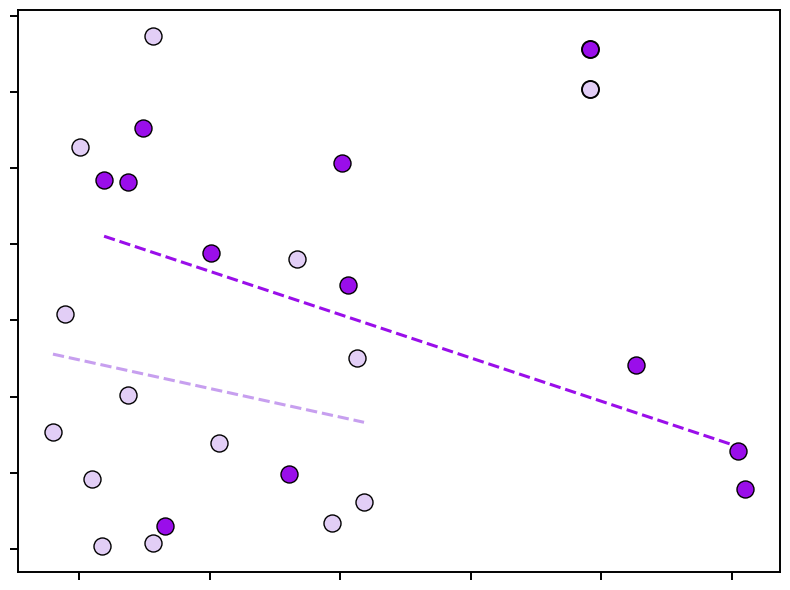

Spearman Correlation Results
-----------------------------------
WT (L4440):
  Spearman rho = -0.5091
  p-value      = 0.1097

cdc-42:
  Spearman rho = -0.2033
  p-value      = 0.5053


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Wild Type (L4440) Data 
wt_di = [
    1.065698039, 1.01919709, 1.101279659,
    1.16107143, 1.037725315, 1.504662624,
    1.049364147, 1.206189358, 1.51047529,
    1.201122985, 1.426323615
]

wt_density = [
    0.000740571, 0.012125386, 0.009710367,
    0.002445335, 0.012060899, 0.003222113,
    0.01382106, 0.008656085, 0.001954102,
    0.012681098, 0.006039088
]

# cdc-42 Data 
cdc42_di = [
    1.017861819, 1.218314456, 1.000821798,
    1.037523024, 0.989372175, 1.193809422,
    1.107423096, 0.980026052, 1.009657092,
    1.056478592, 1.167074902, 1.212572832,
    1.056957022
]

cdc42_density = [
    8.79537E-05, 0.001552362, 0.013182123,
    0.00503887, 0.007696479, 0.000861436,
    0.003482182, 0.003851312, 0.002282384,
    0.016858517, 0.009505266, 0.006256154,
    0.00018734
]


wt_color = '#9A0EEA'      # Violet
cdc_color = '#C79FEF'     # Lavender

# Plot figure

fig, ax = plt.subplots(figsize=(8, 6))

marker_size = 150

# Create scatter plots

# Wild Type
ax.scatter(
    wt_di,
    wt_density,
    s=marker_size,
    facecolors=wt_color,
    edgecolors='black',
    linewidths=1,
    zorder=3
)

# cdc-42
ax.scatter(
    cdc42_di,
    cdc42_density,
    s=marker_size,
    facecolors=(199/255, 159/255, 239/255, 0.5),  # lavender fill, 50% transparent
    edgecolors='black',                            # solid black outline
    linewidths=1,
    zorder=3
)

# Add trendlines

wt_m, wt_b = np.polyfit(wt_di, wt_density, 1)
x_wt = np.linspace(min(wt_di), max(wt_di), 100)

ax.plot(
    x_wt,
    wt_m * x_wt + wt_b,
    color=wt_color,
    linestyle='--',
    linewidth=2.2,
    zorder=2
)

cdc_m, cdc_b = np.polyfit(cdc42_di, cdc42_density, 1)
x_cdc = np.linspace(min(cdc42_di), max(cdc42_di), 100)

ax.plot(
    x_cdc,
    cdc_m * x_cdc + cdc_b,
    color=cdc_color,
    linestyle='--',
    linewidth=2.2,
    alpha=1,
    zorder=2
)

# Inset coloured dots for manual labelling

# WT dot
ax.scatter(
    0.75, 0.93,
    s=marker_size,
    facecolors=wt_color,
    edgecolors='black',
    linewidths=1.4,
    transform=ax.transAxes,
    clip_on=False,
    zorder=5
)

# cdc-42 dot
ax.scatter(
    0.75, 0.86,
    s=marker_size,
    facecolors=(199/255, 159/255, 239/255, 0.5),  # lavender fill, 50% transparent
    edgecolors='black',                            # solid black outline
    linewidths=1.4,
    transform=ax.transAxes,
    clip_on=False,
    zorder=5
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')

ax.set_xticklabels([])
ax.set_yticklabels([])

ax.tick_params(
    axis='both',
    which='major',
    length=6,
    width=1.4,
    direction='out'
)

for spine in ax.spines.values():
    spine.set_linewidth(1.4)

plt.tight_layout()

plt.show()

from scipy.stats import spearmanr

# WT correlation
wt_rho, wt_p = spearmanr(wt_di, wt_density)

# cdc-42 correlation
cdc_rho, cdc_p = spearmanr(cdc42_di, cdc42_density)

print("Spearman Correlation Results")
print("-" * 35)

print(f"WT (L4440):")
print(f"  Spearman rho = {wt_rho:.4f}")
print(f"  p-value      = {wt_p:.4f}")

print()

print(f"cdc-42:")
print(f"  Spearman rho = {cdc_rho:.4f}")
print(f"  p-value      = {cdc_p:.4f}")